In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Pipeline 1: TF-IDF + NMF

This notebook applies TF-IDF vectorization followed by Non-negative Matrix Factorization (NMF) to identify prevalent topics in the consumer complaint narratives.

In [2]:
df = pd.read_csv("/content/complaints_sample_10000.csv")

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

display(df.head())

Dataset shape: (10000, 3)

Columns: ['product', 'narrative', 'word_count']


,product,narrative,word_count
0,credit_reporting,listed fraudulent someone stol social security...,77
1,debt_collection,collection appeared credit report recently deb...,38
2,credit_reporting,quite year exact first started noticing proble...,236
3,credit_reporting,filing forged document court public record fal...,1397
4,mortgages_and_loans,vehicle put chapter bankruptcy significant una...,74


## TF-IDF Vectorization

TF-IDF converts each complaint narrative into a numerical vector. Terms receive higher weights when they are important within a complaint but relatively uncommon across the complete dataset. The vocabulary is limited to 5,000 features to keep the representation computationally manageable.

In [3]:
# Create the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2)
)

# Transform complaint narratives into TF-IDF vectors
tfidf_matrix = tfidf_vectorizer.fit_transform(df["narrative"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Number of complaints:", tfidf_matrix.shape[0])
print("Number of TF-IDF features:", tfidf_matrix.shape[1])

# Display a few vocabulary terms
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nExample features:")
print(feature_names[:20])

TF-IDF matrix shape: (10000, 5000)
Number of complaints: 10000
Number of TF-IDF features: 5000

Example features:
['ability' 'ability obtain' 'able' 'able get' 'able make' 'able pay'
 'able provide' 'able verify' 'absolutely' 'absurd' 'abuse' 'abusive'
 'accept' 'acceptable' 'acceptance' 'accepted' 'accepting' 'access'
 'access account' 'access credit']


## NMF Topic Modelling

Non-negative Matrix Factorization (NMF) is applied to the TF-IDF matrix to discover groups of terms that frequently occur together. Eight topics are initially extracted, and the most important words for each topic are inspected to interpret and assign meaningful topic labels.

In [4]:
# Number of topics to extract
n_topics = 8

# Create and fit the NMF model
nmf_model = NMF(
    n_components=n_topics,
    init="nndsvda",
    random_state=42,
    max_iter=500
)

document_topics = nmf_model.fit_transform(tfidf_matrix)

# Display the top words for each topic
n_top_words = 10

print("Top words for each NMF topic:\n")

for topic_idx, topic in enumerate(nmf_model.components_):
    top_indices = topic.argsort()[-n_top_words:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Top words for each NMF topic:

Topic 1: inquiry, inquiry credit, credit, hard inquiry, hard, report, credit report, credit inquiry, add hard, unauthorized
Topic 2: bank, call, told, would, called, money, back, said, get, time
Topic 3: payment, late, loan, mortgage, late payment, month, due, paid, interest, made
Topic 4: debt, collection, company, agency, collection agency, validation, debt collection, owe, original, collect
Topic 5: account, opened, balance, closed, bank, open, account number, pnc, checking, account account
Topic 6: card, credit card, credit, charge, capital, capital one, one, score, balance, credit score
Topic 7: identity, theft, identity theft, fraudulent, victim, victim identity, fraudulent account, block, information, act
Topic 8: credit, report, credit report, information, reporting, bureau, experian, dispute, inaccurate, item


## Topic Labels and Prevalence

The extracted NMF topics were interpreted using their highest-weighted words. Each complaint is assigned to the topic with the highest NMF weight so that the prevalence of the discovered topics can be compared.

In [5]:
# Assign meaningful labels to the NMF topics
topic_labels = {
    0: "Hard Credit Inquiries",
    1: "Banking Customer Service / Funds Issues",
    2: "Loan & Mortgage Payment Issues",
    3: "Debt Collection & Validation",
    4: "Bank Account Opening / Closure",
    5: "Credit Card & Balance Issues",
    6: "Identity Theft & Fraud",
    7: "Credit Reporting Disputes"
}

# Assign each complaint to its strongest NMF topic
df["nmf_topic"] = document_topics.argmax(axis=1)
df["nmf_topic_label"] = df["nmf_topic"].map(topic_labels)

# Count topic prevalence
topic_counts = df["nmf_topic_label"].value_counts()

print("NMF topic prevalence:")
print(topic_counts)

print("\nTopic percentages:")
print((topic_counts / len(df) * 100).round(2))

NMF topic prevalence:
nmf_topic_label
Banking Customer Service / Funds Issues    2419
Credit Reporting Disputes                  1992
Loan & Mortgage Payment Issues             1485
Bank Account Opening / Closure             1211
Debt Collection & Validation               1125
Credit Card & Balance Issues                868
Identity Theft & Fraud                      513
Hard Credit Inquiries                       387
Name: count, dtype: int64

Topic percentages:
nmf_topic_label
Banking Customer Service / Funds Issues    24.19
Credit Reporting Disputes                  19.92
Loan & Mortgage Payment Issues             14.85
Bank Account Opening / Closure             12.11
Debt Collection & Validation               11.25
Credit Card & Balance Issues                8.68
Identity Theft & Fraud                      5.13
Hard Credit Inquiries                       3.87
Name: count, dtype: float64


## NMF Topic Prevalence Visualization

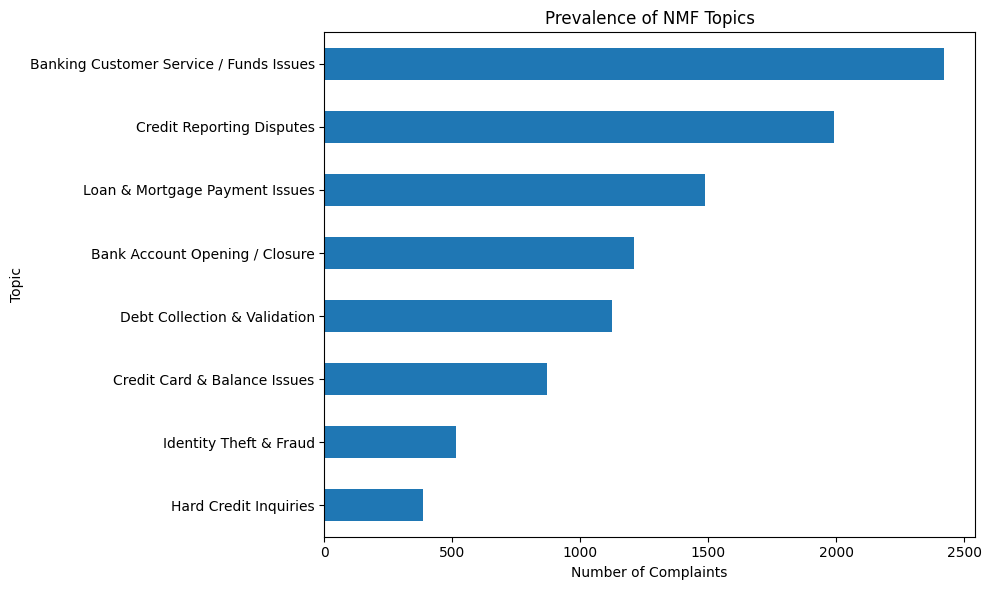

In [6]:
# Plot topic prevalence
plt.figure(figsize=(10, 6))

topic_counts.sort_values().plot(kind="barh")

plt.title("Prevalence of NMF Topics")
plt.xlabel("Number of Complaints")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

## Topic Validation with Representative Complaints

To validate the manually assigned topic labels, representative complaints with the highest NMF weights are inspected for each topic.

In [7]:
# Show the most representative complaint for each topic
pd.set_option("display.max_colwidth", 250)

for topic_num in range(n_topics):
    strongest_doc_index = document_topics[:, topic_num].argmax()

    print(f"\nTopic {topic_num + 1}: {topic_labels[topic_num]}")
    print("Representative complaint:")
    print(df.loc[strongest_doc_index, "narrative"][:500])
    print("-" * 100)


Topic 1: Hard Credit Inquiries
Representative complaint:
soc sec dob address fl unauthorized credit inquiry dear letter formal notice cease unauthorized hard inquiry making credit report also formal demandfor immediately contact credit reporting agency credit bureau organization made inquiry credit history illegal inquiriesremoved advised checking report ensure thefollowing unauthorized inquiry taken credit report line item inquiry detail inquiry credit union inquiry finance inquiry bank inquiry bank inquiry bank inquiry bank inquiry finance xxxxnquir
----------------------------------------------------------------------------------------------------

Topic 2: Banking Customer Service / Funds Issues
Representative complaint:
may concern dealing matter month chase giving explanation fund released opened chase account month ago account long get unemployment every week amount since pandemic started getting direct deposited account week noticed charge account made something authorize call

## Interpretation and Limitations

The TF-IDF + NMF pipeline produced eight interpretable topics. The most prevalent topic was Banking Customer Service / Funds Issues, representing 24.19% of the complaints, followed by Credit Reporting Disputes at 19.92% and Loan & Mortgage Payment Issues at 14.85%.

Inspection of representative complaints showed that most manually assigned topic labels correspond well to the underlying narratives. Topics such as Hard Credit Inquiries, Debt Collection & Validation, Identity Theft & Fraud, and Credit Reporting Disputes were particularly clear.

One limitation is that the Banking Customer Service / Funds Issues topic contains more general terms such as "call", "money", and "bank", making it less specific than some of the other topics. NMF also relies mainly on term-frequency patterns and therefore may not fully capture contextual or semantic similarity between complaints. This limitation will later be compared with the Sentence-BERT + BERTopic pipeline.

In [8]:
# Save complaint-level NMF topic assignments
nmf_results = df[
    ["product", "narrative", "word_count", "nmf_topic", "nmf_topic_label"]
].copy()

nmf_results.to_csv("/content/nmf_topic_assignments.csv", index=False)

# Save topic prevalence summary
nmf_summary = pd.DataFrame({
    "topic": topic_counts.index,
    "count": topic_counts.values,
    "percentage": (topic_counts.values / len(df) * 100).round(2)
})

nmf_summary.to_csv("/content/nmf_topic_summary.csv", index=False)

print("NMF results saved successfully.")
display(nmf_summary)

NMF results saved successfully.


,topic,count,percentage
0,Banking Customer Service / Funds Issues,2419,24.19
1,Credit Reporting Disputes,1992,19.92
2,Loan & Mortgage Payment Issues,1485,14.85
3,Bank Account Opening / Closure,1211,12.11
4,Debt Collection & Validation,1125,11.25
5,Credit Card & Balance Issues,868,8.68
6,Identity Theft & Fraud,513,5.13
7,Hard Credit Inquiries,387,3.87
